### Imports

In [1]:
import sklearn as sk
import gensim as gsn
import numpy as np
import pandas as pd
import os
from matplotlib import pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation as LDA
from sklearn.model_selection import train_test_split
import pyLDAvis as vis

### Load & split data

In [2]:
path = os.getcwd()
df = pd.read_csv(path + "/data/processed_data.csv")
partis_corres = pd.read_csv(path + "/data/partis_correspondance.csv", sep=";")
df = pd.merge(df, partis_corres, how="inner", left_on='titulaire-soutien', right_on='parti')

In [3]:
df_train, df_test = train_test_split(df, test_size=0.2, train_size=0.8)

### Count Vectorizer

In [4]:
stopwords = [x.strip() for x in open('data/stop_words.txt').readlines()]
vectorizer = CountVectorizer(max_features=200, max_df=0.95, min_df=2, stop_words=stopwords)
vectorizer.fit(df_train['text'].to_list())
df_train_counts = vectorizer.transform(df_train['text'])
df_test_counts = vectorizer.transform(df_test['text'])

vocab = vectorizer.vocabulary_.keys()

c:\Users\Utilisateur\Documents\ENSAE\3A\NLP\NLP\venv\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['allã', 'anmoins', 'aoã', 'aprã', 'but', 'celã', 'cembre', 'chã', 'cinquantiã', 'cinquiã', 'delã', 'derriã', 'deuxiã', 'diffã', 'dixiã', 'douziã', 'dã', 'exceptã', 'eã', 'faã', 'fã', 'fã¼r', 'gislatives', 'holã', 'huitiã', 'hã', 'lections', 'lã', 'majoritã', 'malgrã', 'mement', 'mãªme', 'mãªmes', 'neuviã', 'nommã', 'nã', 'ohã', 'ollã', 'olã', 'onziã', 'oã¹', 'particuliã', 'passã', 'piã', 'plutã', 'premiã', 'prã', 'putã', 'quatriã', 'quelqu', 're', 'rement', 'rent', 'rente', 'rentes', 'rents', 'res', 'revoilã', 'septiã', 'sixiã', 'sormais', 'taient', 'tais', 'tait', 'tat', 'tiez', 'tions', 'tre', 'troisiã', 'trã', 'tã', 'voilã', 'votã', 'vrier', 'vã', 'ãªtes', 'ãªtre', 'ãªtreãªtre'] not in stop_words.
  warnings.warn(


In [5]:
train_split = df_train['text'].apply(lambda x: x.split())
doc_lengths = train_split.apply(lambda x: len(x)).to_list()

### LDA

In [6]:
lda = LDA(n_components=10, max_iter=5, random_state=0)
lda.fit(df_train_counts)
topic_term_dists = lda.components_

In [7]:
doc_topic_dists = lda.transform(df_train_counts)

### Visualization

In [8]:
term_frequency = np.array(np.sum(df_train_counts, axis =0)).flatten()

In [9]:
lda_data = {'topic_term_dists': topic_term_dists,
            'doc_topic_dists' : doc_topic_dists,
            'doc_lengths' : doc_lengths,
             'vocab' : vocab,
             'term_frequency' : term_frequency}

lda_viz = vis.prepare(**lda_data)


In [10]:
vis.display(lda_viz)

In [11]:
#modèles pour chaque groupes
dict = {}
for groupe in df['groupe'].unique():
    print(groupe)
    df_groupe = df[df['groupe'] == groupe]
    vectorizer_groupe = CountVectorizer(max_features=200, max_df=0.95, min_df=2, stop_words=stopwords)
    vectorizer_groupe.fit(df_groupe['text'].to_list())
    df_groupe_counts = vectorizer_groupe.transform(df_groupe['text'])
    lda_groupe = LDA(n_components=3 , max_iter=5, random_state=0)
    lda_groupe.fit(df_groupe_counts)
    dict[groupe] = (vectorizer_groupe, lda_groupe)

Indépendant/micro-partis


c:\Users\Utilisateur\Documents\ENSAE\3A\NLP\NLP\venv\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['allã', 'anmoins', 'aoã', 'aprã', 'but', 'celã', 'cembre', 'chã', 'cinquantiã', 'cinquiã', 'delã', 'derriã', 'deuxiã', 'diffã', 'dixiã', 'douziã', 'dã', 'exceptã', 'eã', 'faã', 'fã', 'fã¼r', 'gislatives', 'holã', 'huitiã', 'hã', 'lections', 'lã', 'majoritã', 'malgrã', 'mement', 'mãªme', 'mãªmes', 'neuviã', 'nommã', 'nã', 'ohã', 'ollã', 'olã', 'onziã', 'oã¹', 'particuliã', 'passã', 'piã', 'plutã', 'premiã', 'prã', 'putã', 'quatriã', 'quelqu', 're', 'rement', 'rent', 'rente', 'rentes', 'rents', 'res', 'revoilã', 'septiã', 'sixiã', 'sormais', 'taient', 'tais', 'tait', 'tat', 'tiez', 'tions', 'tre', 'troisiã', 'trã', 'tã', 'voilã', 'votã', 'vrier', 'vã', 'ãªtes', 'ãªtre', 'ãªtreãªtre'] not in stop_words.
  warnings.warn(


Extrême-gauche


c:\Users\Utilisateur\Documents\ENSAE\3A\NLP\NLP\venv\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['allã', 'anmoins', 'aoã', 'aprã', 'but', 'celã', 'cembre', 'chã', 'cinquantiã', 'cinquiã', 'delã', 'derriã', 'deuxiã', 'diffã', 'dixiã', 'douziã', 'dã', 'exceptã', 'eã', 'faã', 'fã', 'fã¼r', 'gislatives', 'holã', 'huitiã', 'hã', 'lections', 'lã', 'majoritã', 'malgrã', 'mement', 'mãªme', 'mãªmes', 'neuviã', 'nommã', 'nã', 'ohã', 'ollã', 'olã', 'onziã', 'oã¹', 'particuliã', 'passã', 'piã', 'plutã', 'premiã', 'prã', 'putã', 'quatriã', 'quelqu', 're', 'rement', 'rent', 'rente', 'rentes', 'rents', 'res', 'revoilã', 'septiã', 'sixiã', 'sormais', 'taient', 'tais', 'tait', 'tat', 'tiez', 'tions', 'tre', 'troisiã', 'trã', 'tã', 'voilã', 'votã', 'vrier', 'vã', 'ãªtes', 'ãªtre', 'ãªtreãªtre'] not in stop_words.
  warnings.warn(


Gauche


...

c:\Users\Utilisateur\Documents\ENSAE\3A\NLP\NLP\venv\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['allã', 'anmoins', 'aoã', 'aprã', 'but', 'celã', 'cembre', 'chã', 'cinquantiã', 'cinquiã', 'delã', 'derriã', 'deuxiã', 'diffã', 'dixiã', 'douziã', 'dã', 'exceptã', 'eã', 'faã', 'fã', 'fã¼r', 'gislatives', 'holã', 'huitiã', 'hã', 'lections', 'lã', 'majoritã', 'malgrã', 'mement', 'mãªme', 'mãªmes', 'neuviã', 'nommã', 'nã', 'ohã', 'ollã', 'olã', 'onziã', 'oã¹', 'particuliã', 'passã', 'piã', 'plutã', 'premiã', 'prã', 'putã', 'quatriã', 'quelqu', 're', 'rement', 'rent', 'rente', 'rentes', 'rents', 'res', 'revoilã', 'septiã', 'sixiã', 'sormais', 'taient', 'tais', 'tait', 'tat', 'tiez', 'tions', 'tre', 'troisiã', 'trã', 'tã', 'voilã', 'votã', 'vrier', 'vã', 'ãªtes', 'ãªtre', 'ãªtreãªtre'] not in stop_words.
  warnings.warn(


Action spécifique


c:\Users\Utilisateur\Documents\ENSAE\3A\NLP\NLP\venv\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['allã', 'anmoins', 'aoã', 'aprã', 'but', 'celã', 'cembre', 'chã', 'cinquantiã', 'cinquiã', 'delã', 'derriã', 'deuxiã', 'diffã', 'dixiã', 'douziã', 'dã', 'exceptã', 'eã', 'faã', 'fã', 'fã¼r', 'gislatives', 'holã', 'huitiã', 'hã', 'lections', 'lã', 'majoritã', 'malgrã', 'mement', 'mãªme', 'mãªmes', 'neuviã', 'nommã', 'nã', 'ohã', 'ollã', 'olã', 'onziã', 'oã¹', 'particuliã', 'passã', 'piã', 'plutã', 'premiã', 'prã', 'putã', 'quatriã', 'quelqu', 're', 'rement', 'rent', 'rente', 'rentes', 'rents', 'res', 'revoilã', 'septiã', 'sixiã', 'sormais', 'taient', 'tais', 'tait', 'tat', 'tiez', 'tions', 'tre', 'troisiã', 'trã', 'tã', 'voilã', 'votã', 'vrier', 'vã', 'ãªtes', 'ãªtre', 'ãªtreãªtre'] not in stop_words.
  warnings.warn(


Ecologiste


c:\Users\Utilisateur\Documents\ENSAE\3A\NLP\NLP\venv\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['allã', 'anmoins', 'aoã', 'aprã', 'but', 'celã', 'cembre', 'chã', 'cinquantiã', 'cinquiã', 'delã', 'derriã', 'deuxiã', 'diffã', 'dixiã', 'douziã', 'dã', 'exceptã', 'eã', 'faã', 'fã', 'fã¼r', 'gislatives', 'holã', 'huitiã', 'hã', 'lections', 'lã', 'majoritã', 'malgrã', 'mement', 'mãªme', 'mãªmes', 'neuviã', 'nommã', 'nã', 'ohã', 'ollã', 'olã', 'onziã', 'oã¹', 'particuliã', 'passã', 'piã', 'plutã', 'premiã', 'prã', 'putã', 'quatriã', 'quelqu', 're', 'rement', 'rent', 'rente', 'rentes', 'rents', 'res', 'revoilã', 'septiã', 'sixiã', 'sormais', 'taient', 'tais', 'tait', 'tat', 'tiez', 'tions', 'tre', 'troisiã', 'trã', 'tã', 'voilã', 'votã', 'vrier', 'vã', 'ãªtes', 'ãªtre', 'ãªtreãªtre'] not in stop_words.
  warnings.warn(


In [ ]:
def top_mots(group , nb_mots=3):
    output = []
    model = dict[group][1]
    features = dict[group][0].get_feature_names_out()
    for _, topic in enumerate(model.components_): # compose output message with top words
        output.append([(features[i], topic[i]) for i in topic.argsort()[:-nb_mots - 1:-1]])# [start (0 if omitted): end : slicing increment]
    return output

In [24]:
for _, topic in enumerate(dict["Ecologiste"][1].components_):
    print(np.max(topic))

264.17431526282775
1909.6805013960536
517.151041668743


In [13]:
group = "Ecologiste"
nb_mots = 3

mots = top_mots(group, nb_mots)
mots

[[('verts', np.float64(264.17431526282775)),
  ('écologie', np.float64(230.43763200193632)),
  ('entente', np.float64(186.96782926021902))],
 [('nature', np.float64(1909.6805013960536)),
  ('animaux', np.float64(1576.6392282200075)),
  ('rassemblement', np.float64(1140.7010302532235))],
 [('vie', np.float64(517.151041668743)),
  ('écologie', np.float64(429.2288607022998)),
  ('ecologie', np.float64(416.2580991648779))]]

In [21]:
for topic in mots:
    for word, proba in topic:
        print(proba)
        break

264.17431526282775
1909.6805013960536
517.151041668743


In [ ]:
plt.bar(range(len(mots)), list)

In [ ]:

y

[[('verts', np.float64(264.17431526282775)),
  ('nature', np.float64(1909.6805013960536)),
  ('vie', np.float64(517.151041668743))],
 [('écologie', np.float64(230.43763200193632)),
  ('animaux', np.float64(1576.6392282200075)),
  ('écologie', np.float64(429.2288607022998))],
 [('entente', np.float64(186.96782926021902)),
  ('rassemblement', np.float64(1140.7010302532235)),
  ('ecologie', np.float64(416.2580991648779))]]

In [37]:
y

[[('verts', np.float64(264.17431526282775)),
  ('nature', np.float64(1909.6805013960536)),
  ('vie', np.float64(517.151041668743))],
 [('écologie', np.float64(230.43763200193632)),
  ('animaux', np.float64(1576.6392282200075)),
  ('écologie', np.float64(429.2288607022998))],
 [('entente', np.float64(186.96782926021902)),
  ('rassemblement', np.float64(1140.7010302532235)),
  ('ecologie', np.float64(416.2580991648779))]]

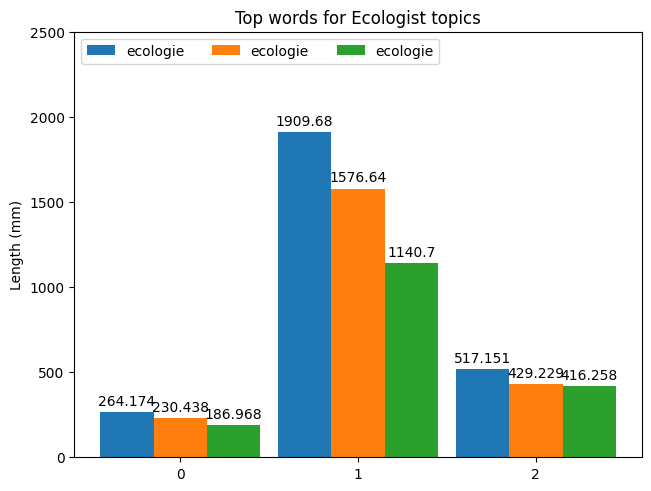

In [48]:
nb_topic = len(mots)
x = np.arange(nb_topic)  # the label locations
width = 0.3  # the width of the bars
multiplier = -1

fig, ax = plt.subplots(layout='constrained')

y = [[mots[x][i] for x in range(nb_topic)] for i in range(nb_mots)]
for n in range(nb_mots):
    words = [y[n][i][0] for i in range(nb_topic)]
    proba = [y[n][i][1] for i in range(nb_topic)]
    
    offset = width * multiplier
    rects = ax.bar(x + offset, proba, width, label=word)
    ax.bar_label(rects, padding=3)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Length (mm)')
ax.set_title('Top words for Ecologist topics')
plt.xticks(np.arange(nb_topic))
ax.legend(loc='upper left', ncols=3)
ax.set_ylim(0, 2500)

plt.show()